# Credit Card Fraud Detection

This project aims to detect fraudulent credit card transactions using machine learning techniques.  


In this project, we perform data analysis, preprocessing, and build classification models to detect fraud.  

## Data Loading

In this section, we load the dataset and inspect its structure.  

In [ ]:
from google.colab import files
files.upload()

Saving creditcardfraud.zip to creditcardfraud.zip
Buffered data was truncated after reaching the output size limit.

In [ ]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analysis

In this section, we explore the dataset to understand its structure and distribution.  

In [ ]:
df.shape

(284807, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Class Distribution

In this section, we examine the distribution of fraudulent and non-fraudulent transactions.  


In [10]:
print(df["Class"].value_counts())

print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Feature Analysis: Time and Amount

In this section, we analyze the distribution of transaction time and transaction amount.  

We also compare fraud and non-fraud transactions.  

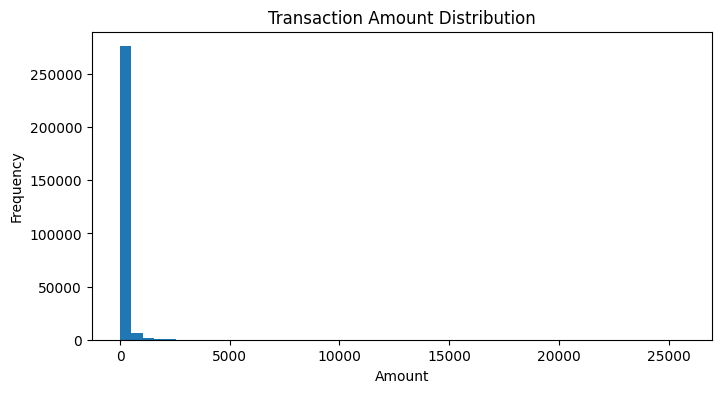

In [11]:
#amount
plt.figure(figsize=(8,4))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

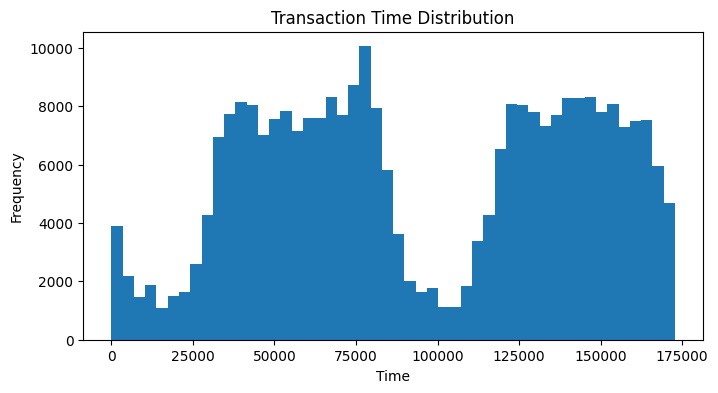

In [12]:
#time
plt.figure(figsize=(8,4))
plt.hist(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

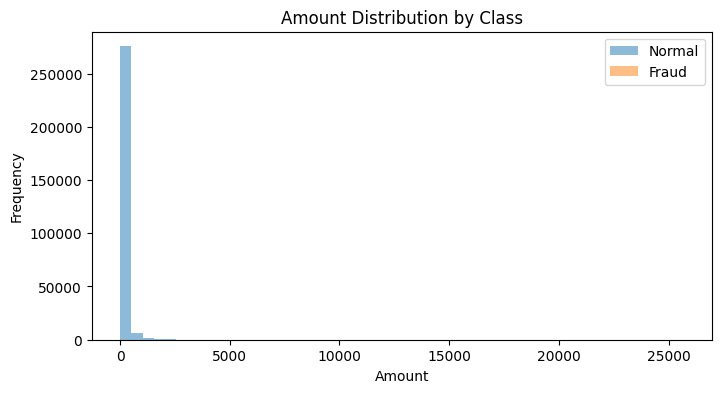

In [13]:
#fraud vs normal
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

plt.figure(figsize=(8,4))
plt.hist(normal["Amount"], bins=50, alpha=0.5, label="Normal")
plt.hist(fraud["Amount"], bins=50, alpha=0.5, label="Fraud")
plt.title("Amount Distribution by Class")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Observations

The transaction amount distribution is highly skewed. Most transactions are of small amounts, while a few transactions have very large values.  

When comparing fraud and normal transactions, fraudulent transactions also tend to occur mostly at lower amounts.  

The transaction time distribution does not show a clear pattern for fraud detection.  

These observations suggest that amount alone may not be sufficient to distinguish fraud transactions.  

## Train-Test Split

In this step, we split the dataset into training and testing sets.  

We use stratified splitting to preserve the class distribution.

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(227845, 30) (56962, 30)
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


## Feature Scaling

In this step, we scale the Time and Amount features.  

Other features are already transformed, so we only scale these two.  

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

print(X_train[["Time", "Amount"]].head())

            Time    Amount
265518  1.411588 -0.322494
180305  0.623141 -0.339764
42664  -1.130680  0.346693
198723  0.794699 -0.327360
82325  -0.748102 -0.008281


## Model 1: Logistic Regression

In this step, we train a Logistic Regression model as a baseline.  

We use class weighting to handle the imbalanced dataset.  

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(roc_auc_score(y_test, y_prob_lr))

[[55478  1386]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

0.9721687370080279


## Model Evaluation (Logistic Regression Model)

The Logistic Regression model achieves high recall for fraud detection.  

However, the precision for the fraud class is very low.  

This means that while the model detects most fraud cases, it also produces many false positives.  

The dataset is highly imbalanced, which affects the model performance.  

ROC-AUC score is relatively high, indicating that the model can distinguish between classes.  

In fraud detection problems, recall is often more important than precision.  

## Model 2: Random Forest

In this step, we train a Random Forest model and compare its performance with Logistic Regression.  

Random Forest is an ensemble learning method that can capture complex patterns in the data.  

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(roc_auc_score(y_test, y_prob_rf))

[[56861     3]
 [   25    73]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

0.952908497036969


## Model Comparison

The Random Forest model achieves a much higher precision for fraud detection compared to Logistic Regression.  

However, its recall is lower than Logistic Regression.  

This means Random Forest produces fewer false positives but misses more fraud cases.  

On the other hand, Logistic Regression achieves very high recall but very low precision.  

In fraud detection problems, there is a trade-off between precision and recall.  

Depending on the business objective, one model may be preferred over the other.  

## Business Perspective

If the goal is to minimize missed fraud cases, Logistic Regression may be preferred due to its high recall.  

If the goal is to reduce false alarms, Random Forest may be preferred due to its high precision.  

## Model Performance Comparison

In this section, we compare the performance of different models using key evaluation metrics.  

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
})

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
})

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.975528   0.060976  0.918367  0.114358  0.972169
1        Random Forest  0.999508   0.960526  0.744898  0.839080  0.952908


## Conclusion

In this project, we developed machine learning models to detect fraudulent credit card transactions.  

The dataset was highly imbalanced, which required careful evaluation using precision, recall, and ROC-AUC metrics.  

Logistic Regression achieved high recall but very low precision, meaning it detected most fraud cases but produced many false positives.  

Random Forest achieved a better balance between precision and recall, making it more reliable in practical scenarios.  

The choice of model depends on the business objective, whether prioritizing fraud detection or minimizing false alarms.